# Sales Data Analysis Project:-

## Problem Statement
The aim  of this project is to analyze or understand patterns of sales data and identify top-performing categories, regions, states, and cities, and observe trends over time.

In [93]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"

## Data Loading

In [94]:
df = pd.read_csv('sales_data_analysis.csv')

## Data Understanding

In [95]:
df.shape

(9800, 18)

In [96]:
df.size

176400

In [97]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [98]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [99]:
df.dtypes 

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [100]:
df.duplicated().sum() 


np.int64(0)

In [101]:
df.isnull().sum()  

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [102]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [104]:
df.describe() 

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [105]:
df['Sales'].describe() 

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [106]:
df['Category'].value_counts()

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

In [107]:
 df['Region'].value_counts()

Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64

In [108]:
 df['State'].value_counts()

State
California              1946
New York                1097
Texas                    973
Pennsylvania             582
Washington               504
Illinois                 483
Ohio                     454
Florida                  373
Michigan                 253
North Carolina           247
Virginia                 224
Arizona                  223
Tennessee                183
Colorado                 179
Georgia                  177
Kentucky                 137
Indiana                  135
Massachusetts            135
Oregon                   122
New Jersey               122
Maryland                 105
Wisconsin                105
Delaware                  93
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              55
Utah                      53
Mississippi               53
South Carolina            42
Louisiana                 41
Nevada  

## Data Cleaning

In [109]:
df.dropna(subset=['Postal Code'], inplace=True)

In [110]:
df['Postal Code'] = df['Postal Code'].astype(int).astype(str)

In [111]:
df = df.drop(columns=['Row ID','Order ID','Customer ID','Customer Name','Product ID'])

In [112]:
df.isnull().sum()

Order Date      0
Ship Date       0
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Product Name    0
Sales           0
dtype: int64

In [113]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y') 

In [114]:
df[['Order Date','Ship Date']].isnull().sum()

Order Date    0
Ship Date     0
dtype: int64

## Feature Engineering

In [115]:

df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month

df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Delivery Days'].describe()

count    9789.000000
mean        3.961181
std         1.750452
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Delivery Days, dtype: float64

In [116]:
df.head()

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales,Order_Year,Order_Month,Delivery Days
0,2017-11-08,2017-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,3
1,2017-11-08,2017-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,3
2,2017-06-12,2017-06-16,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,4
3,2016-10-11,2016-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,7
4,2016-10-11,2016-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,7


In [117]:
df['Month_Name'] = df['Order Date'].dt.month_name()

order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']

df['Month_Name'] = pd.Categorical(df['Month_Name'], categories=order, ordered=True)

# EDA (Analysis):-

## Sales by Category:-

In [118]:
sales_by_Category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
sales_by_Category


,Category,Sales
0,Technology,825856.1130
1,Furniture,723538.4757
2,Office Supplies,703212.8240


### Technology has the highest total sales among all three categories and  after  that Furniture  is second  and  third  is  Office Supplies.

## Sales by Region:-

In [119]:
sales_by_Region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
sales_by_Region

,Region,Sales
0,West,710219.6845
1,East,660589.3560
2,Central,492646.9132
3,South,389151.4590


### The West region is clearly leading in sales first  and second  is East and  Centeral  and  south  give sales less as compare to West and  South .

## Top 3 States by Revenue:-

In [120]:
sales_by_State = df.groupby('State')['Sales'].sum().sort_values(ascending=False).reset_index()
sales_by_State.head(3)

,State,Sales
0,California,446306.4635
1,New York,306361.1470
2,Texas,168572.5322


### California is top first generate sale (around 446K) and after that  New York is second  highly generate sale like (around 306K)  ,Texas is third generate sale (around 169K).

## Top 3 Cities by Revenue (with State):-

In [121]:
sales_by_city = (df.groupby(['State','City'])['Sales'].sum().sort_values(ascending=False).reset_index()) 
sales_by_city.head(3)

,State,City,Sales
0,New York,New York City,252462.547
1,California,Los Angeles,173420.181
2,Washington,Seattle,116106.322


**Insight:**  
New York City, Los Angeles, and Seattle are the top 3 cities by sales.most of the revenue is coming from big metro cities, which is not surprising.

**Business Impact:**  
The company should focus more on these high-performing cities and also explore similar cities where sales have strong growth potential.

###  New York City is generating the most sales as  compare to Los Angeles and Seattle.Los Angeles is  second  top city  and Seattle  is third  top  city who generate sales  from other.so focusing on these  cities can help the business grow further.

## Monthly Sales Trend

In [122]:
monthly_sales = df.groupby(['Order_Year','Order_Month'])['Sales'].sum().reset_index()
monthly_sales

,Order_Year,Order_Month,Sales
0,2015,1,14205.7070
1,2015,2,4519.8920
2,2015,3,55205.7970
3,2015,4,27906.8550
4,2015,5,23644.3030
5,2015,6,34322.9356
6,2015,7,33781.5430
7,2015,8,27117.5365
8,2015,9,81623.5268
9,2015,10,31453.3930


### Sales go up noticeably toward the end of the year, around October to December.  This is probably because of holiday season shopping. It would make sense to plan stock and promotions a little earlier to take advantage of this period.

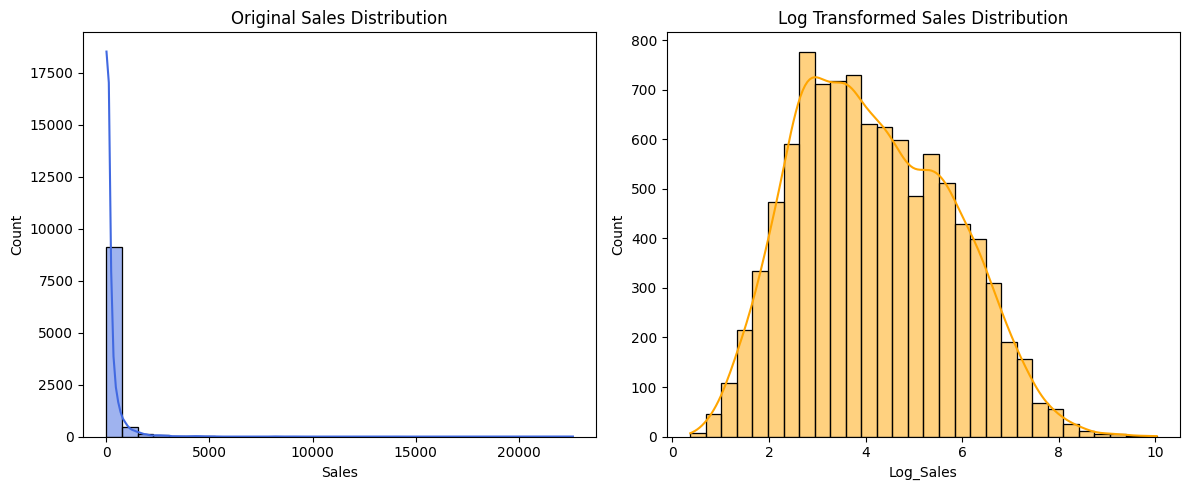

In [123]:
 # Apply log transformation to reduce skewness
df['Log_Sales'] = np.log1p(df['Sales'])

plt.figure(figsize=(12,5))

# Original Sales
plt.subplot(1,2,1)
sns.histplot(df['Sales'], bins=30, kde=True,color='royalblue')
plt.title('Original Sales Distribution')

# Log Transformed Sales
plt.subplot(1,2,2)
sns.histplot(df['Log_Sales'], bins=30, kde=True,color='orange')
plt.title('Log Transformed Sales Distribution')

plt.tight_layout()
plt.show()

In [124]:
df['Sales'].skew(), df['Log_Sales'].skew()

(np.float64(13.053630955201138), np.float64(0.2809213422697102))

**Insight:**  
The sales data is highly skewed, meaning most orders are small while a few large ones push the average up. After applying a log transformation, the distribution becomes more balanced, making the data easier to analyze.

**Business Impact:**  
A small number of high-value transactions contribute disproportionately to total revenue, so these should be monitored carefully. Additionally, log transformation improves data distribution, making it more suitable for accurate analysis and modeling.

np.float64(-0.42720110443888365)

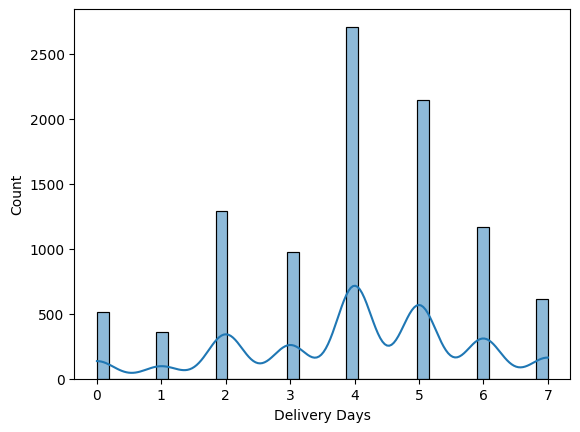

In [125]:
sns.histplot(df['Delivery Days'], kde=True)
df['Delivery Days'].skew()

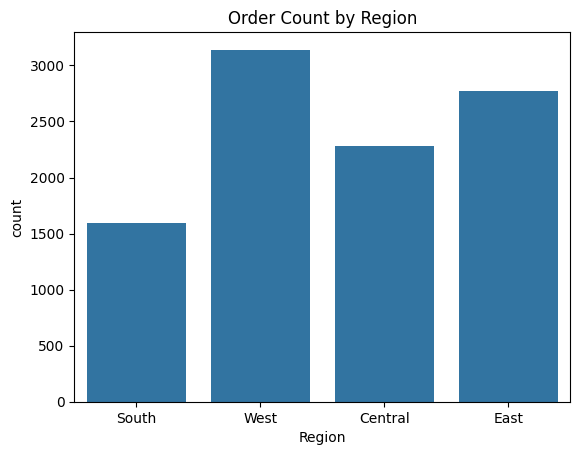

In [126]:
sns.countplot(data = df,x = 'Region')
plt.title('Order Count by Region')
plt.show()

**Insight:**  
Sales are strong in the West and East, but Central and South  are not performing as well. It might be worth looking into whether these regions have less marketing or fewer customers.

**Business Impact:**  
Strong-performing regions should be leveraged further, While strategies from these regions can be applied to improve performance in weaker regions.

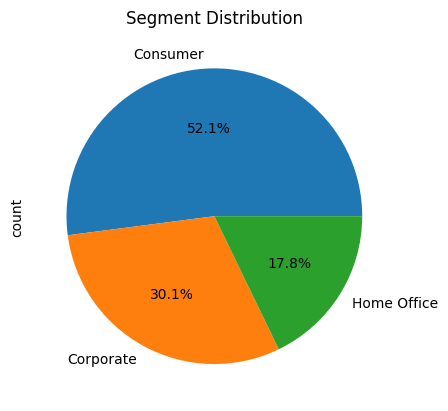

In [127]:
df['Segment'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Segment Distribution')
plt.show()

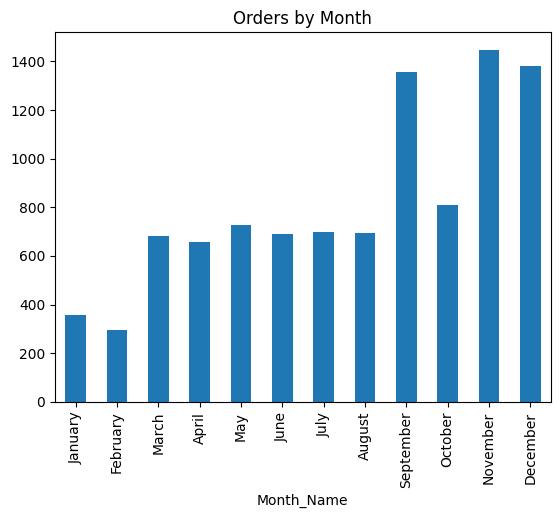

In [128]:
df['Month_Name'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Orders by Month')
plt.show()

# bivariate analysis

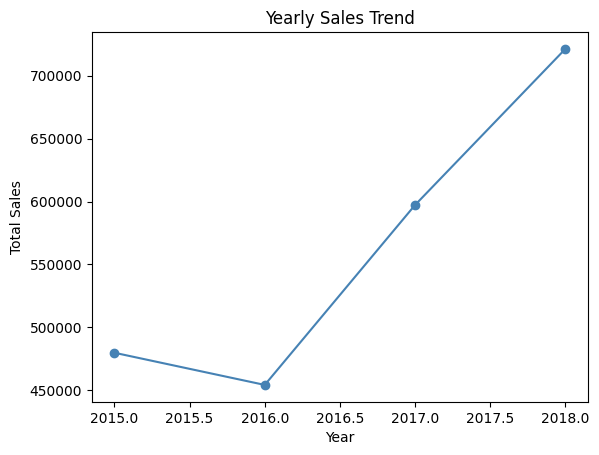

In [129]:
year_sales = df.groupby('Order_Year')['Sales'].sum().reset_index()
year_sales.set_index('Order_Year')['Sales'].plot(kind='line', marker='o', color='steelblue')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()

In [130]:
ct = pd.crosstab(df['Segment'], df['Ship Mode'])
ct

Ship Mode,First Class,Same Day,Second Class,Standard Class
Segment,,,,
Consumer,755,312,1002,3027
Corporate,468,114,589,1777
Home Office,278,112,310,1045


<Axes: xlabel='Ship Mode', ylabel='Segment'>

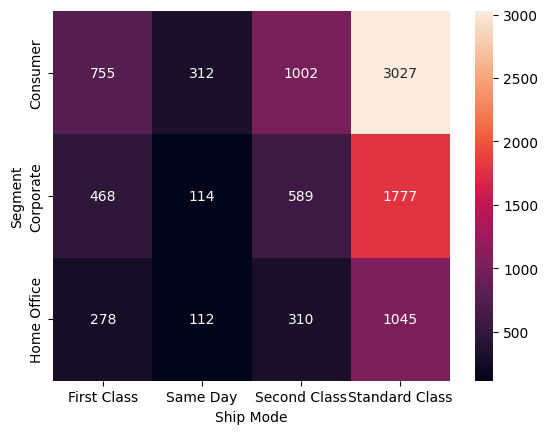

In [131]:
sns.heatmap(ct, annot = True, fmt = 'd')

**Insight:**  
Standard Class is the most commonly used shipping mode across all segments, especially for the Consumer segment. First Class and Same Day are used much less, probably because they cost more.

**Business Impact:**  
This indicates that Standard Class is the most preferred shipping mode across all segments, so the company should ensure its efficiency and reliability to maintain customer satisfaction.

In [132]:
! Pip install kaleido


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [133]:
category= df.groupby('Category')['Sales'].sum().reset_index()

fig = go.Figure(data=[go.Pie(
    labels=category['Category'],
    values=category['Sales'],
    hole=0.4,
    textposition='inside'
)])

fig.update_layout(title="Sales Contribution by Category")
fig.show()
fig.write_image("donut1.png")

**Insight:**  
Technology has the highest share of sales(36.7%),and  office supplies(31.2%) which is  less from Technology but Furniture have(32.1%) which  is  less  from Technology  and  office supplies .office supplies and Furniture both  are near to  equall so do not give  attention on one from these  both office supplies and Furnitur.

**Business Impact:**  
All categories are  important for revenue, but Technology can be slightly prioritised for growth and premium offerings .

In [134]:
seg_sales = df.groupby('Segment')['Sales'].sum().reset_index()

fig = go.Figure(data=[go.Pie(
    labels=seg_sales['Segment'],
    values=seg_sales['Sales'],
    hole=0.4,
    textposition='inside',
    marker=dict(colors=['#264653', '#E76F51', '#F4A261'])
)])

fig.update_layout(title="Sales Contribution by Segment")
fig.show()
fig.write_image("donut2.png")

In [135]:
reg_sales = df.groupby('Region')['Sales'].sum().reset_index()

fig = go.Figure(data=[go.Pie(
    labels=reg_sales['Region'],
    values=reg_sales['Sales'],
    hole=0.4,
    textposition='inside'
    
)])

fig.update_layout(title = "Sales Contribution by Region")
fig.show()
fig.write_image("donut3.png")

#  multivariate analysis

In [136]:
multi = df.groupby(['Product Name','Ship Mode'])['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
multi = multi.sort_values(by='Sales', ascending=True)
fig = px.bar(
    multi,
    x='Sales',
    y='Product Name',
    color='Ship Mode',           
    orientation='h',
    barmode='group',
    title='Top Products by Sales and Ship Mode'
)
fig.show()

**Insight:**  
Top-selling products like the Canon imageCLASS 2200 are mostly shipped using Standard Class. First Class and Second Class are also used, but not as much.

**Business Impact:**  
Since most orders use Standard Class, the company should focus on keeping it smooth and consistent. Other shipping modes can be improved if needed.

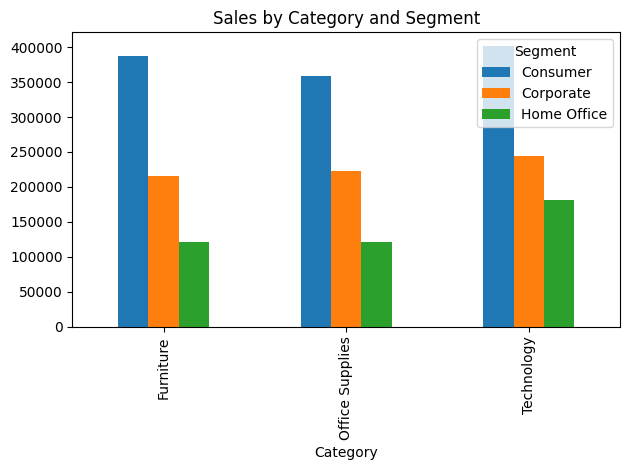

In [137]:
df.groupby(['Category','Segment'])['Sales'].sum().unstack().plot(kind = 'bar')
plt.title('Sales by Category and Segment')
plt.tight_layout()
plt.show()                                

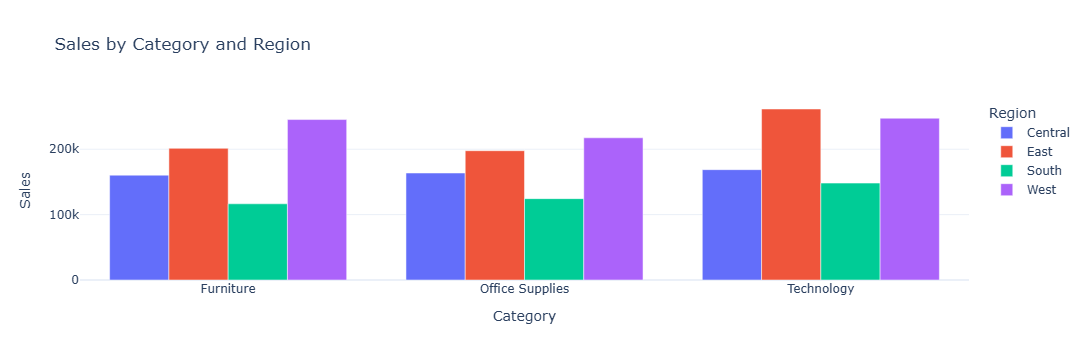

In [138]:
multi = df.groupby(['Category', 'Region'])['Sales'].sum().reset_index()

fig = px.bar(
    multi,
    x='Category',
    y='Sales',
    color='Region',   
    barmode='group',
    title='Sales by Category and Region'
)
fig.show()

## Key Takeaways from the Analysis

**1. Technology is the top category — but all three matter**

Technology brings in the most revenue, but Furniture and Office Supplies are not far behind.so it is  very helpfull on Focusing to Technology. 

**2. West and East regions are strong — Central and South need attention**

Sales are higher in the West and East, while Central and South are not performing as well.it  is good to  determine  why regions  central and  south are  not  generates  sales good  compared to  east  and  west.  

**3. Big cities = big sales**

Cities like New York, Los Angeles, and Seattle genearates high revenue. Targeting similar large cities could be a good way to grow further.

**4. End of year is the peak — prepare early**

Sales increase toward the end of the year, especially from October to December. Planning inventory and marketing a little earlier can help make the most of this period . and  at this  time offering discounts  generates  more revenue.

**5. A few large orders drive a lot of revenue**

Most orders are small, but a few high-value orders contribute a big part of the total sales. These larger orders are worth tracking separately.

**6. Standard shipping is what most customers go for**

Most orders use Standard Class instead of faster options. This shows people are okay with normal delivery time, so the company should focus on keeping Standard delivery smooth and consistent, because most orders depend on it.

##  Tools Used   
Python (Pandas, NumPy)  
Data Visualization: Matplotlib, Seaborn, Plotly